In [3]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# Fetch dataset
breast_cancer = fetch_ucirepo(id=17)

# Features
X = breast_cancer.data.features

# Target
y = breast_cancer.data.targets

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget values:")
print(y.head())

Feature shape: (569, 30)
Target shape: (569, 1)

First 5 rows:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target values:
  Diagnosis
0         M
1         M
2         M
3         M
4         M


In [5]:
print("Dataset Information:")
print(X.info())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nTarget distribution:")
print(y.value_counts())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16

In [6]:
# Convert target to a Series
y = y.iloc[:, 0]

# Convert target labels
y = y.map({'B': 0, 'M': 1})

print("Target values after encoding:")
print(y.value_counts())

Target values after encoding:
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [7]:
# Check whether ID column exists
print(X.columns)

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='str')


In [8]:
# Remove ID column if present
if 'ID' in X.columns:
    X = X.drop(columns=['ID'])

print("Feature shape after removing ID:", X.shape)

Feature shape after removing ID: (569, 30)


In [9]:
print("Total missing values:", X.isnull().sum().sum())

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

print("Missing values after preprocessing:", X.isnull().sum().sum())

Total missing values: 0
Missing values after preprocessing: 0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data standardized.")

Training data standardized.


In [12]:
linear_svm = SVC(kernel='linear', C=1.0)

linear_svm.fit(X_train_scaled, y_train)

y_pred = linear_svm.predict(X_test_scaled)

print("Linear SVM training completed.")

Linear SVM training completed.


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Linear Kernel SVM Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Linear Kernel SVM Performance
--------------------------------
Accuracy  : 0.9649
Precision : 1.0000
Recall    : 0.9048
F1 Score  : 0.9500


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Benign', 'Malignant']
))

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 4 38]]


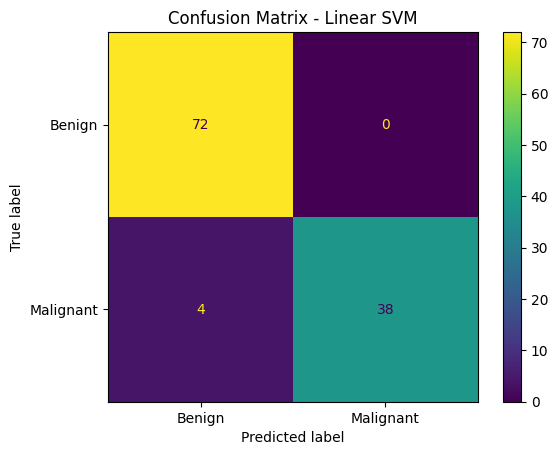

In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Malignant']
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [17]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'C': 0.01}
Best cross-validation accuracy: 0.9692307692307693


In [18]:
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

print("Tuned Linear SVM Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")

Tuned Linear SVM Performance
--------------------------------
Accuracy  : 0.9561
Precision : 1.0000
Recall    : 0.8810
F1 Score  : 0.9367


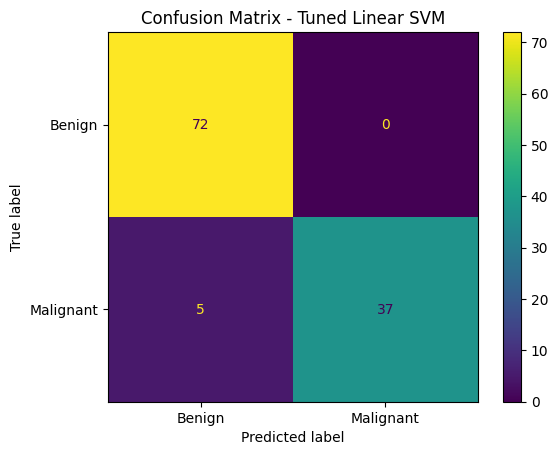

In [19]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=['Benign', 'Malignant']
)

disp.plot()
plt.title("Confusion Matrix - Tuned Linear SVM")
plt.show()

In [20]:
results = []

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    
    model = SVC(kernel='linear', C=C)
    model.fit(X_train_scaled, y_train)
    
    prediction = model.predict(X_test_scaled)
    
    results.append({
        'C': C,
        'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction),
        'Recall': recall_score(y_test, prediction),
        'F1 Score': f1_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)

display(results_df)

,C,Accuracy,Precision,Recall,F1 Score
0,0.001,0.921053,1.000,0.785714,0.880000
1,0.010,0.956140,1.000,0.880952,0.936709
2,0.100,0.982456,1.000,0.952381,0.975610
3,1.000,0.964912,1.000,0.904762,0.950000
4,10.000,0.973684,1.000,0.928571,0.962963
5,100.000,0.929825,0.925,0.880952,0.902439


1. SVM successfully classified the Breast Cancer dataset into Benign and Malignant classes.

2. Feature standardization was important because SVM is sensitive to differences in feature scales.

3. The Linear Kernel performed well because the dataset contains useful patterns that can be separated using a linear decision boundary.

4. Hyperparameter C controls the trade-off between a wider margin and classification errors.

5. The tuned model can be compared with the original model using Accuracy, Precision, Recall and F1 Score.

6. Recall is particularly important in medical classification because incorrectly classifying a malignant tumor as benign can be more serious than a false positive.

In [21]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [22]:
wine = fetch_ucirepo(id=109)

X_wine = wine.data.features
y_wine = wine.data.targets

print("Feature shape:", X_wine.shape)
print("Target shape:", y_wine.shape)

print("\nFirst 5 rows:")
display(X_wine.head())

print("\nTarget values:")
display(y_wine.head())

Feature shape: (178, 13)
Target shape: (178, 1)

First 5 rows:


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Target values:


,class
0,1
1,1
2,1
3,1
4,1


In [23]:
print("Dataset information:")
X_wine.info()

print("\nMissing values:")
print(X_wine.isnull().sum().sum())

print("\nClass distribution:")
print(y_wine.value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  


In [24]:
y_wine = y_wine.iloc[:, 0]

print("Classes:")
print(y_wine.unique())

print("\nClass distribution:")
print(y_wine.value_counts())

Classes:
[1 2 3]

Class distribution:
class
2    71
1    59
3    48
Name: count, dtype: int64


In [25]:
wine_scaler = StandardScaler()

X_wine_scaled = wine_scaler.fit_transform(X_wine)

print("Original number of features:", X_wine.shape[1])
print("Standardized data shape:", X_wine_scaled.shape)

Original number of features: 13
Standardized data shape: (178, 13)


In [26]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_wine_scaled)

print("Original shape:", X_wine_scaled.shape)
print("Transformed shape:", X_pca_2.shape)

Original shape: (178, 13)
Transformed shape: (178, 2)


In [27]:
explained_variance = pca_2.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"Principal Component {i}: {variance:.4f}")

print("\nTotal variance retained by 2 components:",
      explained_variance.sum())

Explained Variance Ratio:
Principal Component 1: 0.3620
Principal Component 2: 0.1921

Total variance retained by 2 components: 0.5540633835693527


In [28]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_wine_scaled)

explained_variance_full = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_full)

variance_table = pd.DataFrame({
    'Principal Component': range(1, len(explained_variance_full) + 1),
    'Explained Variance': explained_variance_full,
    'Cumulative Variance': cumulative_variance
})

display(variance_table)

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


In [29]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Minimum number of components required to retain at least 95% variance:",
    n_components_95
)

print(
    "Variance retained:",
    cumulative_variance[n_components_95 - 1]
)

Minimum number of components required to retain at least 95% variance: 10
Variance retained: 0.9616971684450644


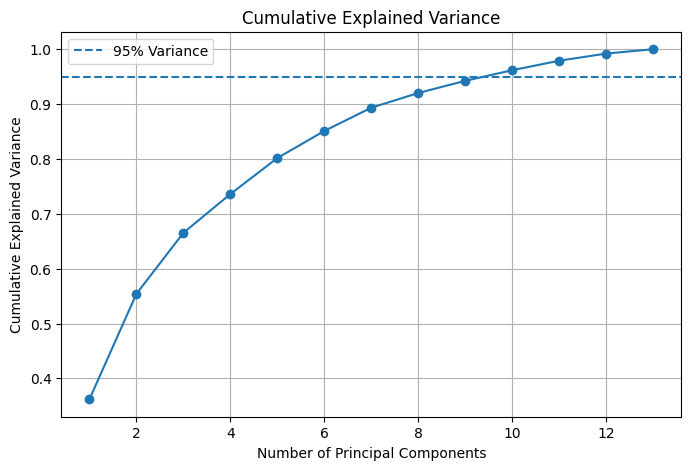

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
pca_df = pd.DataFrame(
    X_pca_2,
    columns=['PC1', 'PC2']
)

pca_df['Class'] = y_wine.values

display(pca_df.head())

,PC1,PC2,Class
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1


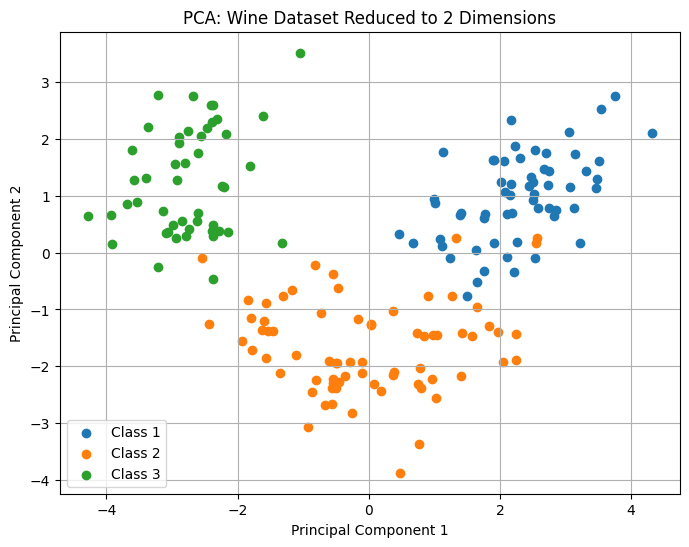

In [32]:
plt.figure(figsize=(8, 6))

for wine_class in sorted(pca_df['Class'].unique()):
    
    subset = pca_df[pca_df['Class'] == wine_class]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Class {wine_class}'
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Wine Dataset Reduced to 2 Dimensions")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X_wine.columns,
    columns=['PC1', 'PC2']
)

display(loadings)

,PC1,PC2
Alcohol,0.144329,0.483652
Malicacid,-0.245188,0.224931
Ash,-0.002051,0.316069
Alcalinity_of_ash,-0.239320,-0.010591
Magnesium,0.141992,0.299634
Total_phenols,0.394661,0.065040
Flavanoids,0.422934,-0.003360
Nonflavanoid_phenols,-0.298533,0.028779
Proanthocyanins,0.313429,0.039302
Color_intensity,-0.088617,0.529996


In [34]:
print("Top features contributing to PC1:")
display(
    loadings['PC1']
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop features contributing to PC2:")
display(
    loadings['PC2']
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

Top features contributing to PC1:


Flavanoids                      0.422934
Total_phenols                   0.394661
0D280_0D315_of_diluted_wines    0.376167
Proanthocyanins                 0.313429
Nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64


Top features contributing to PC2:


Color_intensity    0.529996
Alcohol            0.483652
Proline            0.364903
Ash                0.316069
Magnesium          0.299634
Name: PC2, dtype: float64

In [35]:
print("Interpretation of Principal Components:\n")

print("PC1 is mainly influenced by:")
print(
    loadings['PC1']
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("\nPC2 is mainly influenced by:")
print(
    loadings['PC2']
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("""
PC1 represents the direction in the dataset that captures
the largest amount of variation.

PC2 represents the next most important direction of variation
and is orthogonal (uncorrelated) to PC1.

The exact meaning of PC1 and PC2 depends on the features having
the largest absolute loading values.
""")

Interpretation of Principal Components:

PC1 is mainly influenced by:
Flavanoids                      0.422934
Total_phenols                   0.394661
0D280_0D315_of_diluted_wines    0.376167
Proanthocyanins                 0.313429
Nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

PC2 is mainly influenced by:
Color_intensity    0.529996
Alcohol            0.483652
Proline            0.364903
Ash                0.316069
Magnesium          0.299634
Name: PC2, dtype: float64

PC1 represents the direction in the dataset that captures
the largest amount of variation.

PC2 represents the next most important direction of variation
and is orthogonal (uncorrelated) to PC1.

The exact meaning of PC1 and PC2 depends on the features having
the largest absolute loading values.



In [36]:
comparison = pd.DataFrame({
    'Property': [
        'Number of Features',
        'Number of Samples',
        'Dimensionality',
        'Information Retained'
    ],
    'Original Dataset': [
        X_wine.shape[1],
        X_wine.shape[0],
        '13 dimensions',
        '100%'
    ],
    'PCA Dataset (2 Components)': [
        X_pca_2.shape[1],
        X_pca_2.shape[0],
        '2 dimensions',
        f'{pca_2.explained_variance_ratio_.sum() * 100:.2f}%'
    ]
})

display(comparison)

,Property,Original Dataset,PCA Dataset (2 Components)
0,Number of Features,13,2
1,Number of Samples,178,178
2,Dimensionality,13 dimensions,2 dimensions
3,Information Retained,100%,55.41%


In [37]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print("Original shape:", X_wine_scaled.shape)
print("LDA transformed shape:", X_lda.shape)

Original shape: (178, 13)
LDA transformed shape: (178, 2)


In [38]:
lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

lda_df['Class'] = y_wine.values

display(lda_df.head())

,LD1,LD2,Class
0,-4.700244,1.979138,1
1,-4.301958,1.170413,1
2,-3.420720,1.429101,1
3,-4.205754,4.002871,1
4,-1.509982,0.451224,1


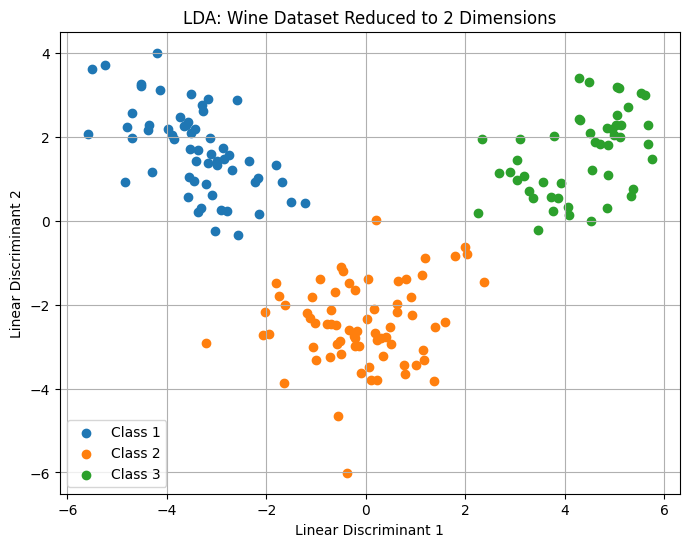

In [39]:
plt.figure(figsize=(8, 6))

for wine_class in sorted(lda_df['Class'].unique()):
    
    subset = lda_df[lda_df['Class'] == wine_class]
    
    plt.scatter(
        subset['LD1'],
        subset['LD2'],
        label=f'Class {wine_class}'
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA: Wine Dataset Reduced to 2 Dimensions")
plt.legend()
plt.grid(True)

plt.show()

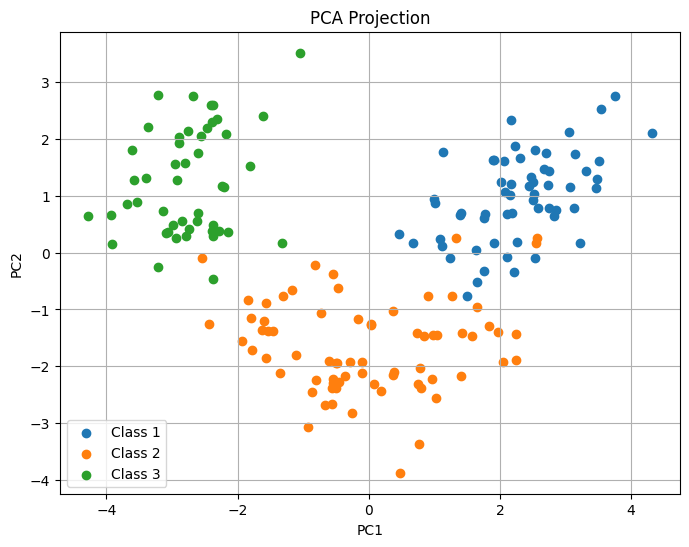

In [40]:
plt.figure(figsize=(8, 6))

for wine_class in sorted(pca_df['Class'].unique()):
    
    subset = pca_df[pca_df['Class'] == wine_class]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Class {wine_class}'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend()
plt.grid(True)

plt.show()

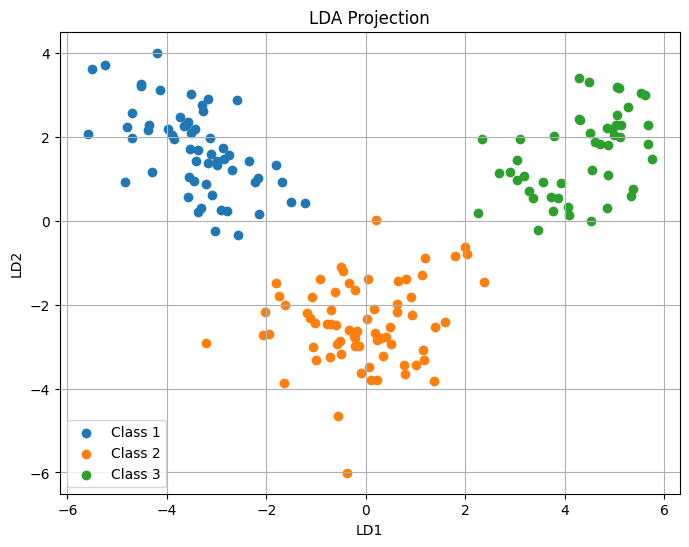

In [41]:
plt.figure(figsize=(8, 6))

for wine_class in sorted(lda_df['Class'].unique()):
    
    subset = lda_df[lda_df['Class'] == wine_class]
    
    plt.scatter(
        subset['LD1'],
        subset['LD2'],
        label=f'Class {wine_class}'
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection")
plt.legend()
plt.grid(True)

plt.show()

SVM:
The Support Vector Machine successfully classified the Breast Cancer
Wisconsin dataset. Standardization improved the suitability of the
features for SVM. The linear kernel produced good classification
performance, and tuning the C parameter allowed the model to find
a better balance between margin size and classification errors.

PCA:
PCA reduced the Wine dataset from 13 original features to 2 principal
components for visualization. The first two components retain a
significant portion of the total variance. However, reducing the
dataset to only two components may discard some information.

The number of components required to retain at least 95% of the
variance was determined using cumulative explained variance.

PCA is useful for dimensionality reduction, visualization, noise
reduction and reducing computational complexity.

LDA:
LDA reduced the 13-dimensional Wine dataset to two linear discriminants.
Unlike PCA, LDA uses class labels and specifically attempts to maximize
the separation between different classes.

Therefore, LDA generally provides better class separability when the
objective is classification, whereas PCA focuses on preserving the
maximum overall variance.

SVM is a supervised learning algorithm used for classification.
PCA is an unsupervised dimensionality reduction technique.
LDA is a supervised dimensionality reduction technique.

SVM -> Classification,
PCA -> Maximum variance preservation,
LDA -> Maximum class separation
